In [2]:
import pandas as pd 

In [4]:
df = pd.read_csv("../Datasets/bank_ds.csv")
df

,Unnamed: 0,Education,Family,Income,Personal Loan,Mortgage,Age,Securities Account,CreditCard
0,0,1,4,49,0,0,25,1,0
1,1,1,3,34,0,0,45,1,0
2,2,1,1,11,0,0,39,0,0
3,3,2,1,100,0,0,35,0,0
4,4,2,4,45,0,0,35,0,1
...,...,...,...,...,...,...,...,...,...
4995,4995,3,1,40,0,0,29,0,0
4996,4996,1,4,15,0,85,30,0,0
4997,4997,3,2,24,0,0,63,0,0
4998,4998,2,3,49,0,0,65,0,0


In [5]:
df.drop(columns=['Unnamed: 0'],inplace=True)

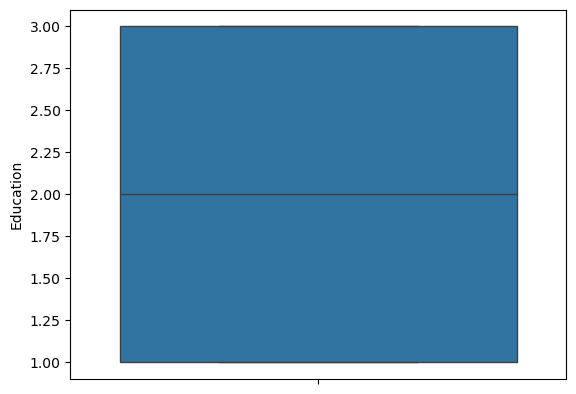

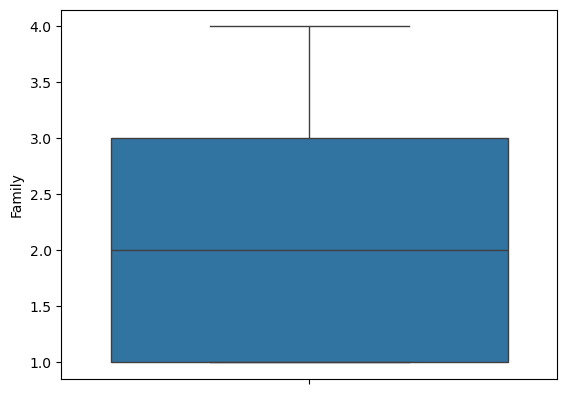

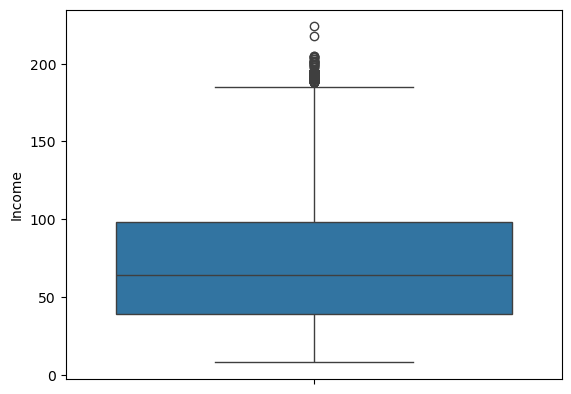

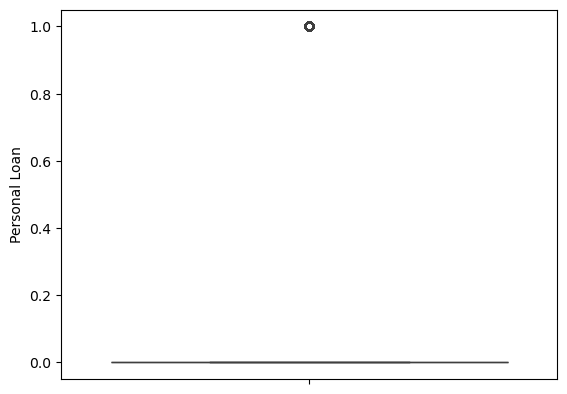

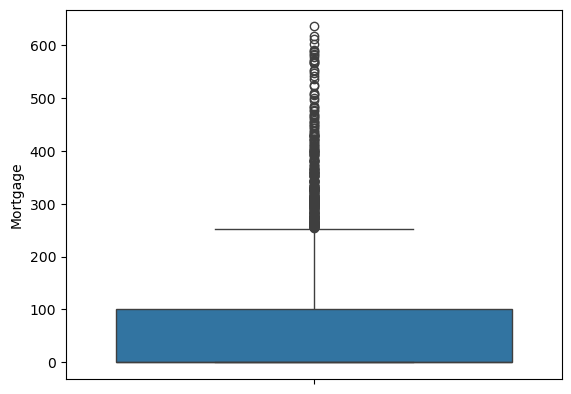

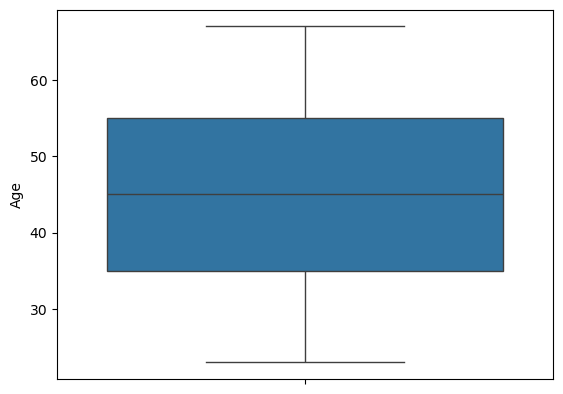

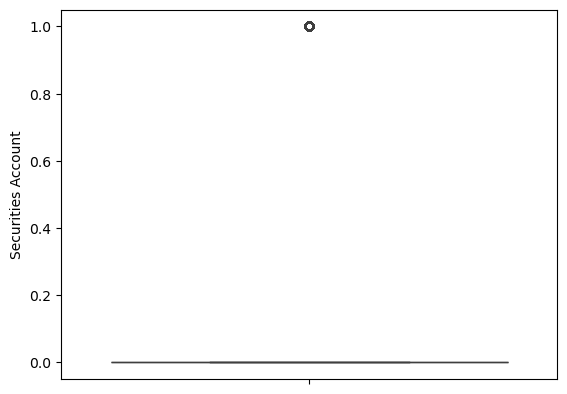

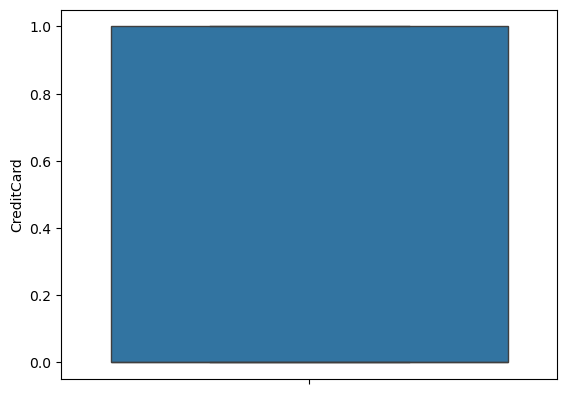

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
for column in df.columns:
    plt.figure()
    sns.boxplot(y = df[column]) 

In [11]:
df['Personal Loan'].value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

In [16]:
df.corr()

,Education,Family,Income,Personal Loan,Mortgage,Age,Securities Account,CreditCard
Education,1.000000,0.064929,-0.187524,0.136722,-0.033327,0.041334,-0.010812,-0.011014
Family,0.064929,1.000000,-0.157501,0.061367,-0.020445,-0.046418,0.019994,0.011588
Income,-0.187524,-0.157501,1.000000,0.502462,0.206806,-0.055269,-0.002616,-0.002385
Personal Loan,0.136722,0.061367,0.502462,1.000000,0.142095,-0.007726,0.021954,0.002802
Mortgage,-0.033327,-0.020445,0.206806,0.142095,1.000000,-0.012539,-0.005411,-0.007231
Age,0.041334,-0.046418,-0.055269,-0.007726,-0.012539,1.000000,-0.000436,0.007681
Securities Account,-0.010812,0.019994,-0.002616,0.021954,-0.005411,-0.000436,1.000000,-0.015028
CreditCard,-0.011014,0.011588,-0.002385,0.002802,-0.007231,0.007681,-0.015028,1.000000


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [31]:
x = df.drop(columns=['Personal Loan'])
y = df['Personal Loan']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

In [33]:
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\Yugesh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy : ",accuracy_score(y_test, y_pred))
print("Confusion Matix : \n",confusion_matrix(y_test, y_pred))

Accuracy :  0.9513333333333334
Confusion Matix : 
 [[1348   24]
 [  49   79]]
